In [1]:
import pandas as pd

df = pd.read_csv("dirty_cafe_sales.csv")
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [2]:
import numpy as np

df.replace(["UNKNOWN", "ERROR", "NaN"], np.nan, inplace=True)
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [3]:
df.isnull().sum().sum() / df.size * 100

np.float64(12.6025)

In [4]:
df["Quantity"] = df["Quantity"].astype("Int64")
df["Price Per Unit"] = df["Price Per Unit"].astype("Float64")
df["Total Spent"] = df["Total Spent"].astype("Float64")

In [5]:
total_spent = df["Quantity"] * df["Price Per Unit"]
df["Total Spent"] = df["Total Spent"].fillna(total_spent)

price_per_unit = df["Total Spent"] / df["Quantity"]
df["Price Per Unit"] = df["Price Per Unit"].fillna(price_per_unit)

quantity = df["Total Spent"] / df["Price Per Unit"]
df["Quantity"] = df["Quantity"].fillna(quantity)

cols = ["Total Spent", "Price Per Unit", "Quantity", "Transaction Date"]
df = df.dropna(subset=cols)
df.isna().sum()

Transaction ID         0
Item                 921
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      2997
Location            3760
Transaction Date       0
dtype: int64

In [6]:
df.isnull().sum().sum() / df.size * 100

np.float64(10.118608328940432)

In [7]:
def mode_or_nan(x):
    m = x.mode()
    return m[0] if not m.empty else pd.NA

group_cols = list(df.columns[2:5])
mode_series = df.groupby(group_cols)['Item'].transform(mode_or_nan)

df['Item'] = df['Item'].fillna(mode_series)
df.isna().sum()

Transaction ID         0
Item                   0
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      2997
Location            3760
Transaction Date       0
dtype: int64

In [8]:
fill_columns = df.columns[5:7]
group_modes = df.groupby('Item')[fill_columns].agg(lambda x: x.mode().iloc[0])

for col in fill_columns:
    mode_map = group_modes[col]
    df[col] = df[col].fillna(df['Item'].map(mode_map))

df.isna().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [9]:
(df.size / 100000) * 100

75.88000000000001

In [10]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], format="%Y-%m-%d")

In [85]:
df.iloc[:, :-1].describe()

,Quantity,Price Per Unit,Total Spent
count,9485.0,9485.0,9485.0
mean,3.022035,2.949236,8.92388
std,1.420106,1.279082,6.003071
min,1.0,1.0,1.0
25%,2.0,2.0,4.0
50%,3.0,3.0,8.0
75%,4.0,4.0,12.0
max,5.0,5.0,25.0


<Axes: xlabel='Item', ylabel='Total Spent'>

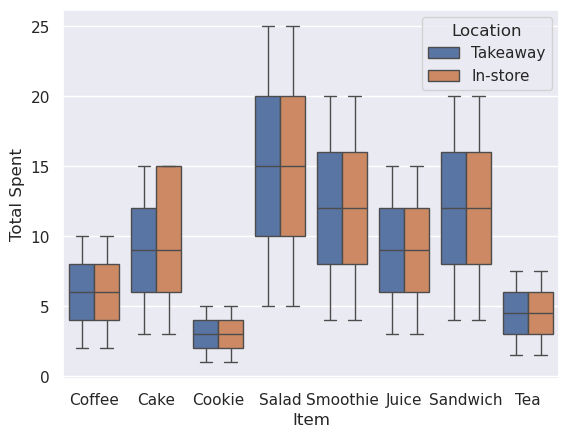

In [11]:
import seaborn as sns
sns.set_theme(style="darkgrid")

sns.boxplot(
    data=df,
    x="Item", y="Total Spent",
    hue="Location"
)

<Axes: xlabel='Total Spent', ylabel='Item'>

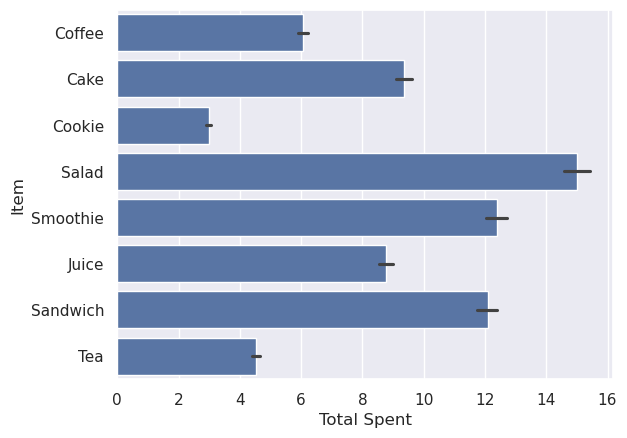

In [12]:
sns.barplot(
    df,
    x="Total Spent", y="Item"
)

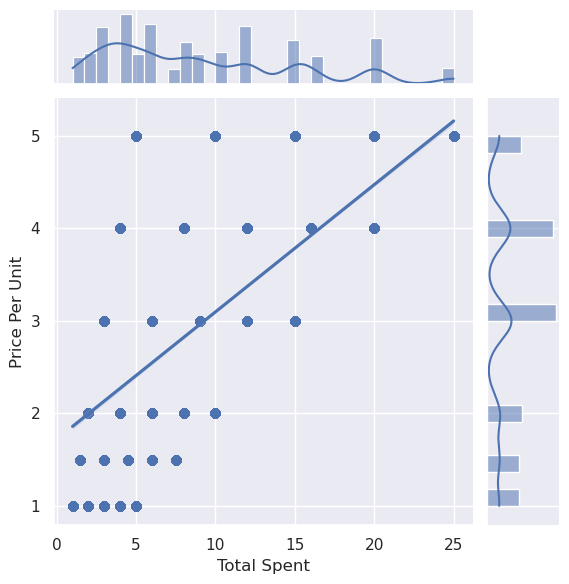

In [13]:
sns.jointplot(
    data=df,
    x="Total Spent", y="Price Per Unit",
    kind="reg" 
)